In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
#load dataset
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

In [4]:
#convert dataset into dataframe
data = pd.DataFrame(X, columns=diabetes.feature_names)

data['target'] = y

print(data.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [5]:
#target into classification
y = (y > y.mean()).astype(int)

In [6]:
#splitting dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
#logistic regression model
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

#random forest model
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

#svm moddel
svm_model = SVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.7640449438202247
Random Forest Accuracy: 0.7415730337078652
SVM Accuracy: 0.7303370786516854


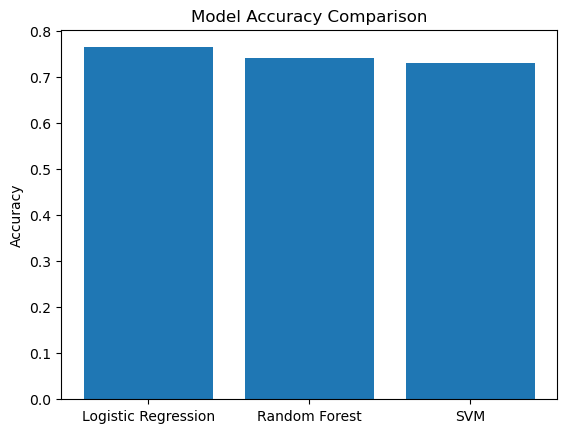

In [9]:
#comapring model
models = ['Logistic Regression',
          'Random Forest',
          'SVM']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)
]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

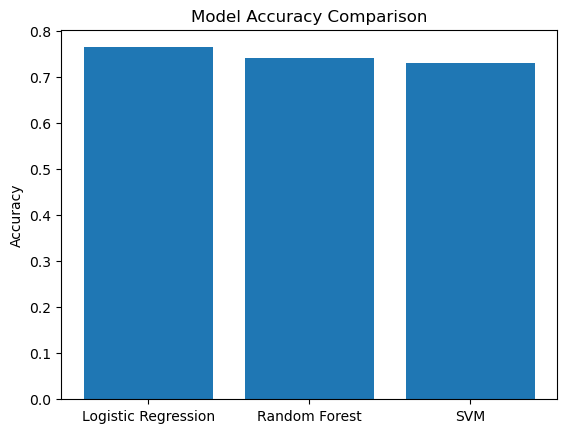

In [10]:
#best model selection 
models = ['Logistic Regression',
          'Random Forest',
          'SVM']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)
]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

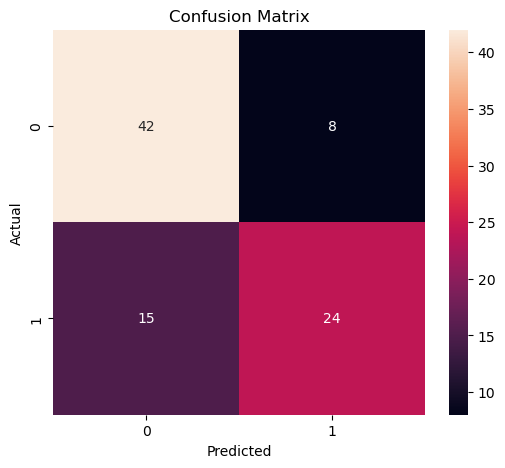

              precision    recall  f1-score   support

           0       0.74      0.84      0.79        50
           1       0.75      0.62      0.68        39

    accuracy                           0.74        89
   macro avg       0.74      0.73      0.73        89
weighted avg       0.74      0.74      0.74        89



In [11]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


#clasification report 
print(classification_report(y_test, y_pred_rf))


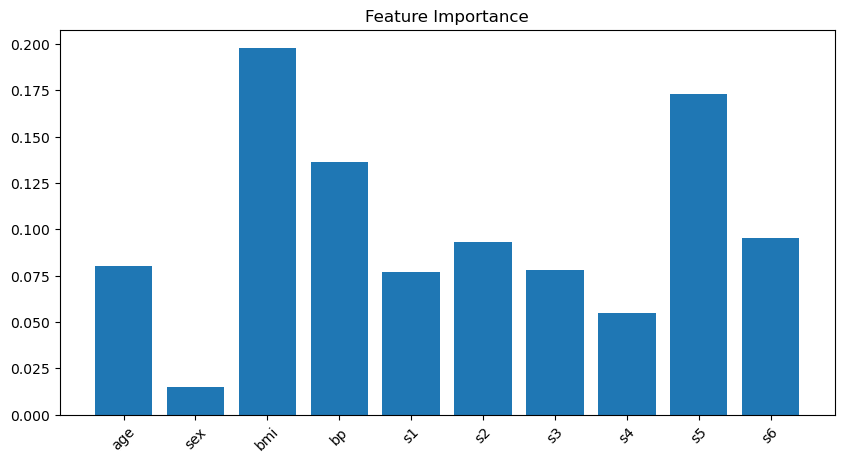

In [12]:
#feature importance 
importance = rf_model.feature_importances_

features = diabetes.feature_names

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

In [14]:
#user input prediction system
sample_data = [[
    0.05,   # age
    0.02,   # sex
    0.03,   # bmi
    0.01,   # bp
    0.04,   # s1
    0.02,   # s2
    0.01,   # s3
    0.03,   # s4
    0.02,   # s5
    0.01    # s6
]]

prediction = rf_model.predict(sample_data)

if prediction[0] == 1:
    print("Disease Risk Detected")
else:
    print("No Disease Risk")

Disease Risk Detected


In [15]:
#disease risk in percentage 
probability = rf_model.predict_proba(sample_data)

print("Disease Probability:",
      probability[0][1] * 100, "%")

Disease Probability: 75.0 %


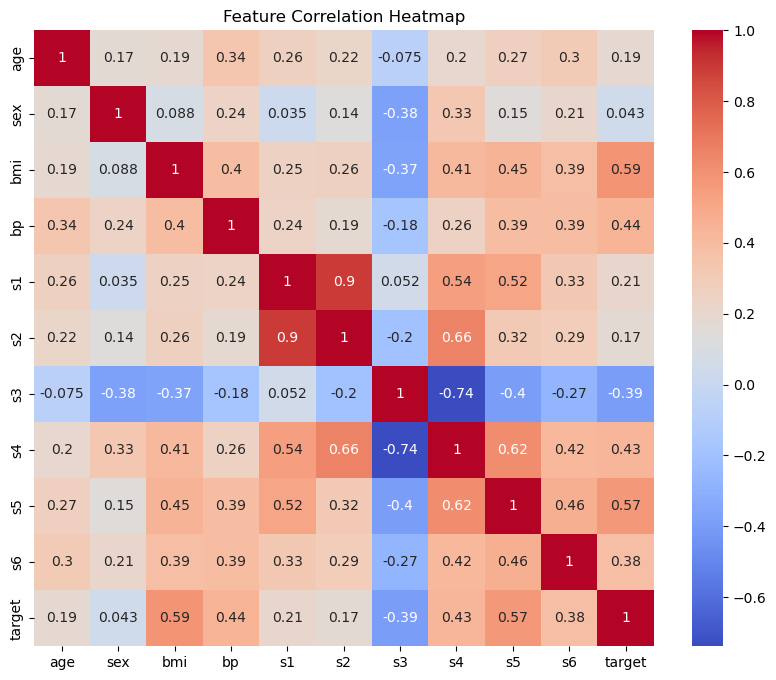

In [16]:
#correlation heatmap 
plt.figure(figsize=(10,8))

sns.heatmap(data.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [17]:
#best model recommendation 
best_accuracy = max(accuracies)

best_model = models[accuracies.index(best_accuracy)]

print("Recommended Model:", best_model)

Recommended Model: Logistic Regression


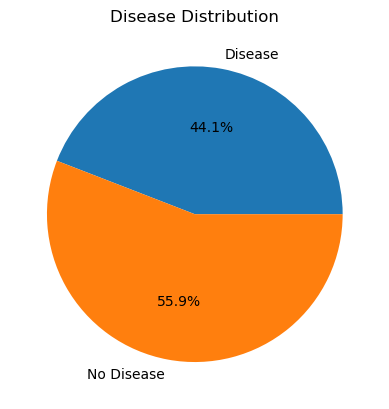

In [18]:
#pie chart of disease distribution 
labels = ['Disease', 'No Disease']

sizes = [sum(y), len(y)-sum(y)]

plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%')

plt.title("Disease Distribution")

plt.show()

In [ ]:
#Example

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = {
    'Fever': [1,1,0,1,0,1,0,1,0,1],
    'Cough': [1,1,0,0,1,1,0,1,0,1],
    'Headache': [1,0,1,1,0,1,0,1,1,0],
    'Fatigue': [1,1,0,1,0,1,0,1,0,1],
    'Breathing_Problem': [0,1,0,1,0,1,0,1,0,1],
    'Disease': [1,1,0,1,0,1,0,1,0,1]
}
df = pd.DataFrame(data)
print(df.head())

X = df.drop('Disease', axis=1)
y = df['Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:",
      accuracy_score(y_test, y_pred))


fever = int(input("Do you have Fever? (1/0): "))
cough = int(input("Do you have Cough? (1/0): "))
headache = int(input("Do you have Headache? (1/0): "))
fatigue = int(input("Do you have Fatigue? (1/0): "))
breathing = int(input("Do you have Breathing Problem? (1/0): "))
user_data = [[
    fever,
    cough,
    headache,
    fatigue,
    breathing
]]
prediction = model.predict(user_data)


if prediction[0] == 1:
    print("Disease Detected")
else:
    print("No Disease Detected")

    
probability = model.predict_proba(user_data)
print("Disease Probability:",
      probability[0][1] * 100, "%")

if prediction[0] == 1:
    print("Recommendation: Please consult a doctor.")
else:
    print("Recommendation: Maintain healthy lifestyle.")

   Fever  Cough  Headache  Fatigue  Breathing_Problem  Disease
0      1      1         1        1                  0        1
1      1      1         0        1                  1        1
2      0      0         1        0                  0        0
3      1      0         1        1                  1        1
4      0      1         0        0                  0        0
Accuracy: 1.0


In [ ]:
#save model 
